230063B
Athukorala U.R.

In [1]:
!pip install opencv-python

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Q1 — Piecewise intensity transform

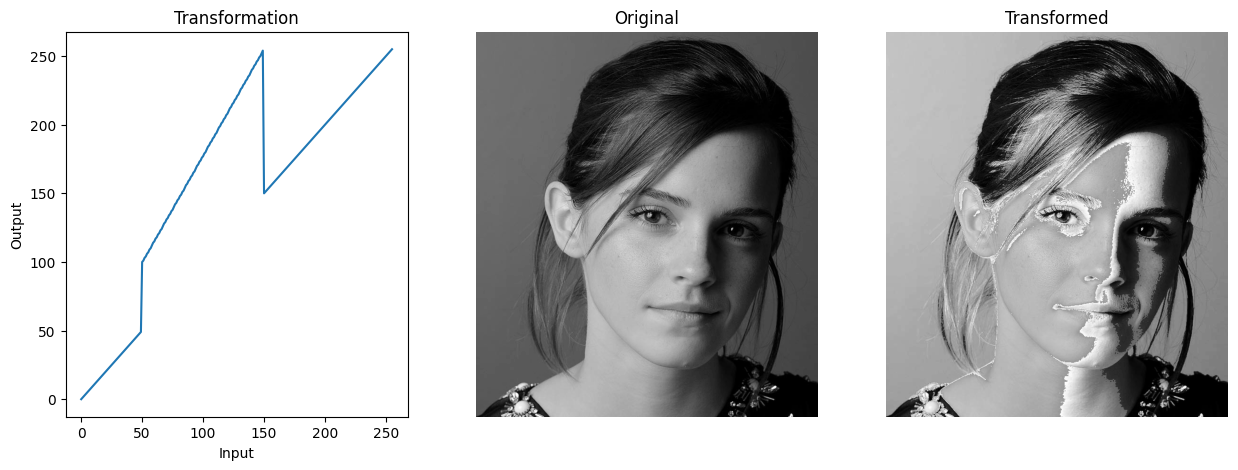

In [5]:
def intensity_transform(im, segments):
    lut = np.zeros(256, dtype=np.uint8)
    for (x0, y0), (x1, y1) in segments:
        xs = np.arange(x0, x1 + 1)
        ys = y0 if x1 == x0 else y0 + (y1 - y0) * (xs - x0) / (x1 - x0)
        lut[x0:x1 + 1] = np.clip(ys, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut)

img = cv2.imread('emma.png', cv2.IMREAD_GRAYSCALE)
assert img is not None, "check the filename/path"

segments = [((0, 0), (49, 49)), ((50, 100), (149, 254)), ((150, 150), (255, 255))]
transformed = intensity_transform(img, segments)

# Plot the transformation curve
lut_plot = np.zeros(256, dtype=np.uint8)
for (x0, y0), (x1, y1) in segments:
    xs = np.arange(x0, x1 + 1)
    ys = y0 if x1 == x0 else y0 + (y1 - y0) * (xs - x0) / (x1 - x0)
    lut_plot[x0:x1 + 1] = np.clip(ys, 0, 255)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(range(256), lut_plot); ax[0].set_title("Transformation"); ax[0].set_xlabel("Input"); ax[0].set_ylabel("Output")
ax[1].imshow(img, cmap='gray'); ax[1].set_title("Original"); ax[1].axis('off')
ax[2].imshow(transformed, cmap='gray'); ax[2].set_title("Transformed"); ax[2].axis('off')
plt.show()

the jump at x=50 forces mid-range shadows to leap to a brighter value, keeping the darker values upto x=50 at the normal intensity range while the second segment stretches midtones for more contrast; the drop at x=150 recompresses bright details to the normal level.We can see that the contrast between left and right sides of the face and the contrast near the hairline compared to skin is increased.

Q2 — Accentuate white/gray matter

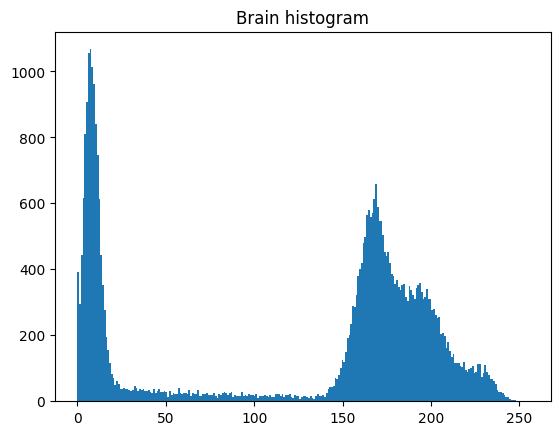

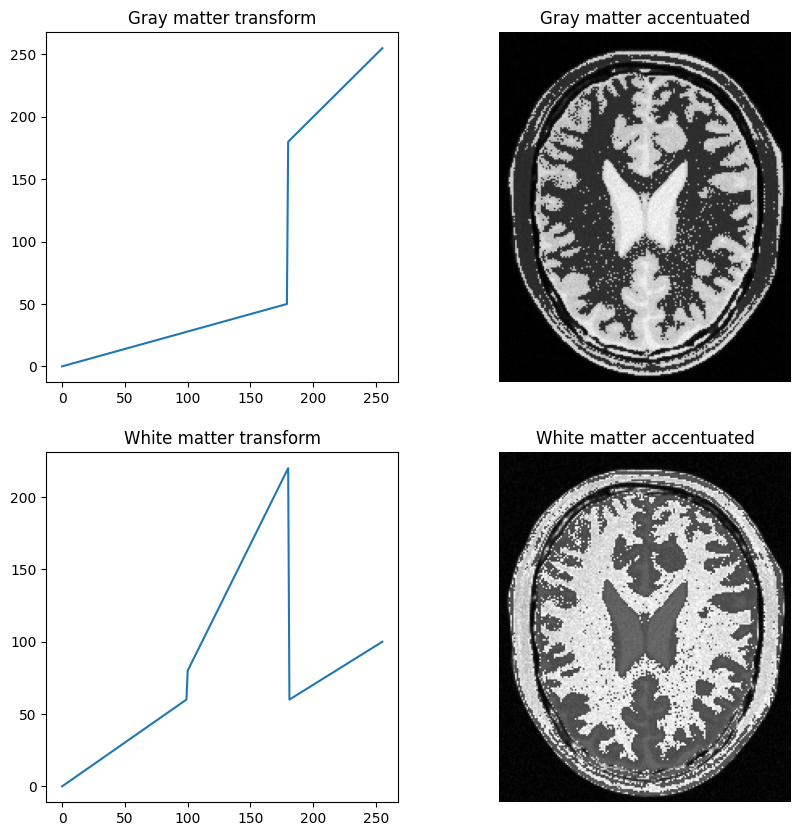

In [16]:
brain = cv2.imread('brain.jpeg', cv2.IMREAD_GRAYSCALE)
assert brain is not None

plt.hist(brain.ravel(), bins=256, range=(0,255))
plt.title("Brain histogram"); plt.show()

# (a) Accentuate gray matter (bright range ~180-255)
gray_segments = [((0,0),(179,50)), ((180,180),(255,255))]
gray_boost = intensity_transform(brain, gray_segments)

# (b) Accentuate white matter (mid range ~100-180)
white_segments = [((0,0),(99,60)), ((100,80),(180,220)), ((181,60),(255,100))]
white_boost = intensity_transform(brain, white_segments)

fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0,0].plot(range(256), [
    (v*50/179 if v<=179 else
     180+(v-180)*(255-180)/(255-180))
    for v in range(256)
])
ax[0,0].set_title("Gray matter transform")
ax[0,1].imshow(gray_boost, cmap='gray'); ax[0,1].set_title("Gray matter accentuated"); ax[0,1].axis('off')

ax[1,0].plot(range(256), [
    (v*60/99 if v<=99 else
     (80+(v-100)*140/80 if v<=180 else
      60+(v-181)*40/74))
    for v in range(256)
])
ax[1,0].set_title("White matter transform")
ax[1,1].imshow(white_boost, cmap='gray'); ax[1,1].set_title("White matter accentuated"); ax[1,1].axis('off')
plt.show()

Gray matter transform: Below x=180, all intensities are compressed down into a dim 0–50 band — this flattens the skull, background, and white matter tracts into near uniform darkness, removing their visual competition. From x=180 onward, the curve holds an identity slope, leaving the brightest tissue.
White matter transform: The low range (0–99) is compressed into a dim 0–60 band, suppressing it. The critical move happens in the 100–180 range, where the white matter gets stretched out into a much wider 80–220 output band, sharply increasing local contrast. Everything above 180 then drops and recompresses into a narrow 60–100 output range, which is a deliberate discontinuity: it suppresses the already-bright tissue so it doesn't visually dominate, letting the now-stretched white matter stand out instead.


In [ ]:
Q3 — Gamma correction

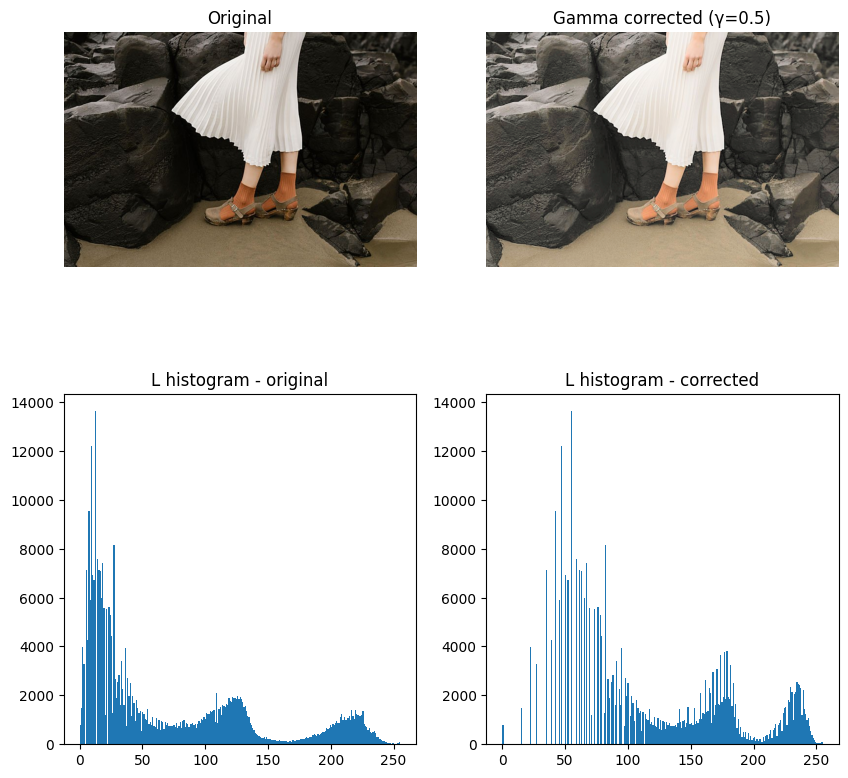

In [25]:
img3 = cv2.imread('whiteskirt.jpeg')
assert img3 is not None

lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

gamma = 0.5
L_norm = L / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = L_gamma.astype(np.uint8)

lab_corrected = cv2.merge([L_gamma, a, b])
img3_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0,0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)); ax[0,0].set_title("Original"); ax[0,0].axis('off')
ax[0,1].imshow(cv2.cvtColor(img3_corrected, cv2.COLOR_BGR2RGB)); ax[0,1].set_title(f"Gamma corrected (γ={gamma})"); ax[0,1].axis('off')
ax[1,0].hist(L.ravel(), bins=256, range=(0,255)); ax[1,0].set_title("L histogram - original")
ax[1,1].hist(L_gamma.ravel(), bins=256, range=(0,255)); ax[1,1].set_title("L histogram - corrected")
plt.show()

Unlike the piecewise linear transforms before, this is a smooth power curve applied uniformly across the whole 0–255 range rather than distinct compressed/stretched segments. Because γ<1, the curve's slope is steep near x=0 and flattens progressively as x increases toward 255 — meaning a shadow pixel around L=10 gets pushed up disproportionately, while a highlight pixel around L=200 barely moves. Here the everywhere gradually, concentrated at the low end. We can see the previously near-black volcanic rocks gain visible texture and separation between individual rock faces, while the already-bright white dress shows almost no visible change, which confirms that the curve selectively expanded the dark end of the range without touching the bright end.

Q4 — Vibrance via saturation boost

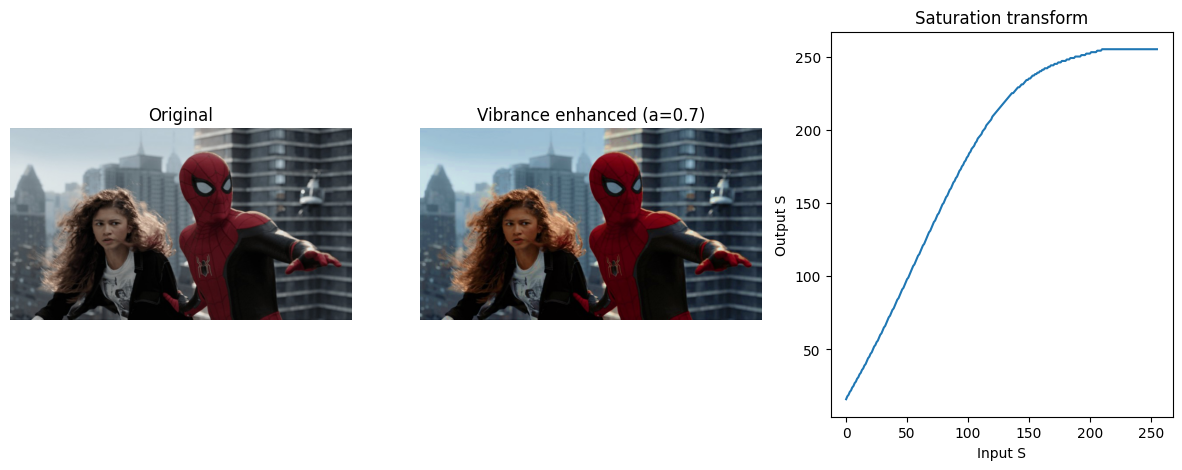

In [35]:
img4 = cv2.imread('spiderman.jpeg')
assert img4 is not None

hsv = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

a = 0.7     # tune this, report your chosen value
sigma = 70

x = np.arange(256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype(np.uint8)

S_new = cv2.LUT(S, f)
hsv_new = cv2.merge([H, S_new, V])
img4_vibrant = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img4_vibrant, cv2.COLOR_BGR2RGB)); ax[1].set_title(f"Vibrance enhanced (a={a})"); ax[1].axis('off')
ax[2].plot(x, f); ax[2].set_title("Saturation transform"); ax[2].set_xlabel("Input S"); ax[2].set_ylabel("Output S")
plt.show()

The transformation only affects the middle of the saturation range, since the Gaussian term peaks at x=128 and decays to near-zero toward both x=0 and x=255, Colors that are already very gray or already very vivid barely change, because the bump is almost zero at both ends. Colors sitting in the middle, moderately colorful, not gray but not super vivid either get pushed up the most, since that's where the bump is tallest. In the image, this means dull, medium-toned colors like the background and clothing look noticeably more vibrant, while pure grays and the already-bright red suit has only a slight bump in vibrance, giving it a more natural boost instead of making everything look artificially oversaturated.Here a gives the height of the saturation bump and lower a values gives a barely noticeable enhancement and higher a values tend to bump the saturation values very high giving the especially the skin an almost artificial orange color. Therefore a=0.6 or a=0.7 gives the best results according to preferences.

Q5 — Histogram equalization 

[ WARN:0@129438.603] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


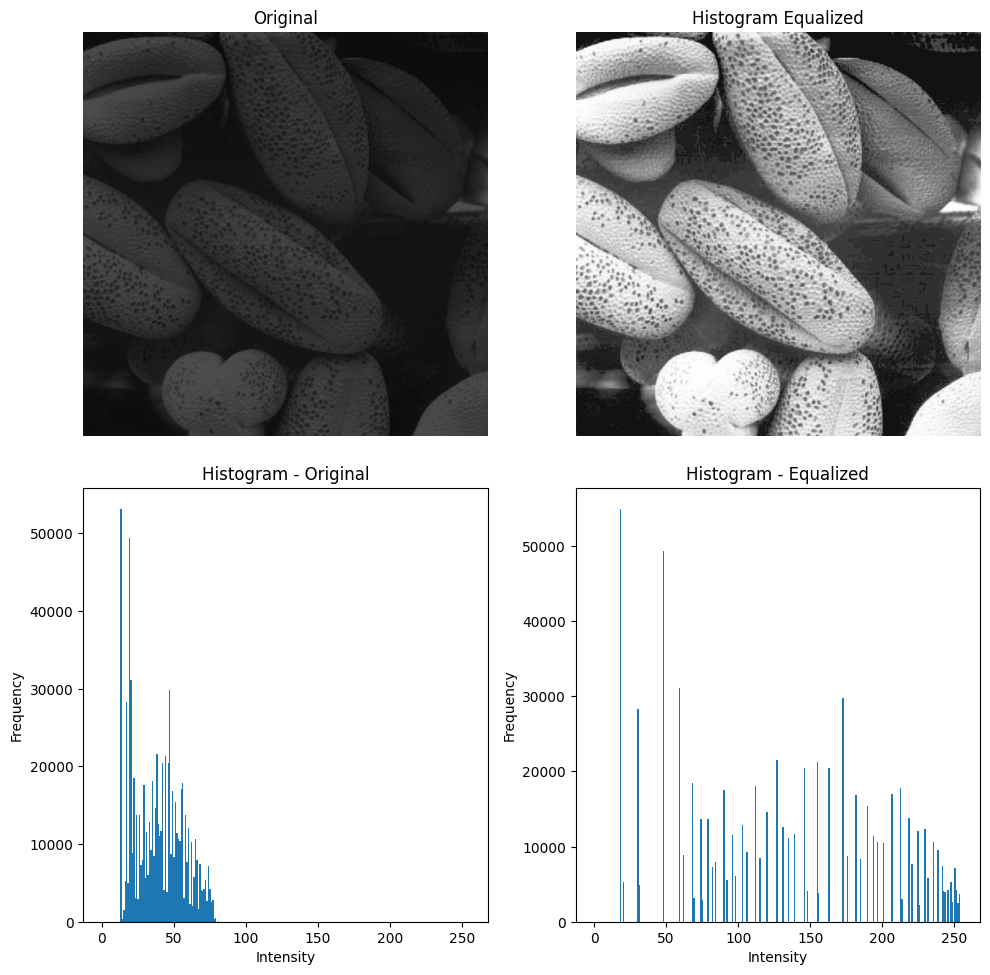

In [42]:
def my_equalize_hist(img_gray):
    hist, _ = np.histogram(img_gray.ravel(), bins=256, range=(0, 255))
    cdf = np.cumsum(hist)
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    lut = cdf_normalized.astype(np.uint8)
    return cv2.LUT(img_gray, lut)

# Load Fig. 5 (shells image)
shells = cv2.imread('shells.tif')
assert shells is not None

# Apply custom equalization
shells_eq = my_equalize_hist(shells)

# Display original vs equalized images, and their histograms
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ax[0, 0].imshow(shells, cmap='gray')
ax[0, 0].set_title("Original")
ax[0, 0].axis('off')

ax[0, 1].imshow(shells_eq, cmap='gray')
ax[0, 1].set_title("Histogram Equalized")
ax[0, 1].axis('off')

ax[1, 0].hist(shells.ravel(), bins=256, range=(0, 255))
ax[1, 0].set_title("Histogram - Original")
ax[1, 0].set_xlabel("Intensity")
ax[1, 0].set_ylabel("Frequency")

ax[1, 1].hist(shells_eq.ravel(), bins=256, range=(0, 255))
ax[1, 1].set_title("Histogram - Equalized")
ax[1, 1].set_xlabel("Intensity")
ax[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The original shells image has a narrow histogram concentrated in a limited range of intensities making it harder to identify individual shell textures and details. After equalization the histogram spreads to occupy most of the 0-255 intensity range improving the overall contrast of the image.
This method requires no manual tuning of parameters or breakpoints unlike the piecewise linear or gamma transforms used in the earlier questions. This uses solely the images own cumulative distribution to map pixel intensities into a wider range. With this intensity values which are densely packed together gets mapped to a wider range and values which rarely occurs gets compressed into a narrower output band.

Q6 — Equalizing the foreground

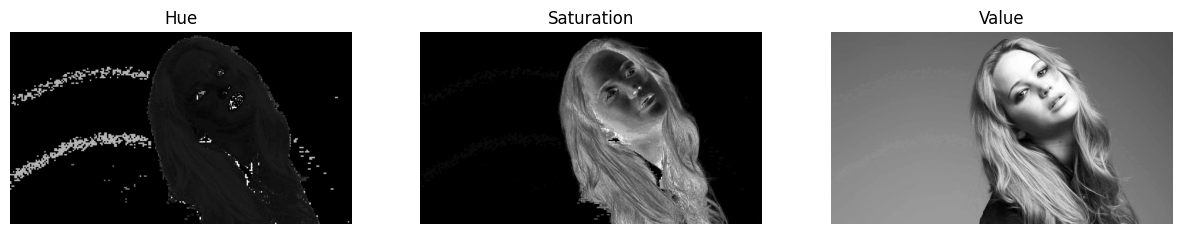

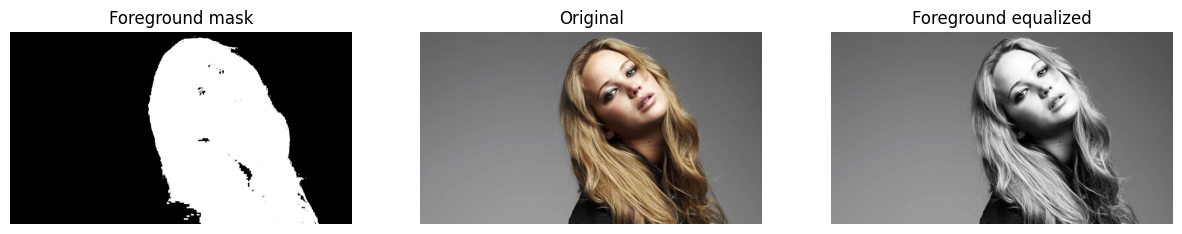

In [50]:
img6 = cv2.imread('lawrence.png')
assert img6 is not None

hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
H6, S6, V6 = cv2.split(hsv6)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(H6, cmap='gray'); ax[0].set_title("Hue"); ax[0].axis('off')
ax[1].imshow(S6, cmap='gray'); ax[1].set_title("Saturation"); ax[1].axis('off')
ax[2].imshow(V6, cmap='gray'); ax[2].set_title("Value"); ax[2].axis('off')
plt.show()

threshold_val = 15
_, mask = cv2.threshold(S6, threshold_val, 255, cv2.THRESH_BINARY)

foreground = cv2.bitwise_and(img6, img6, mask=mask)
foreground_gray = cv2.cvtColor(foreground, cv2.COLOR_BGR2GRAY)

# Using the slide's formula: t[k] = (L-1)/(M*N) * cdf[k], g = t[f]
fg_eq_gray = my_equalize_hist(foreground_gray)
fg_eq_gray = cv2.bitwise_and(fg_eq_gray, fg_eq_gray, mask=mask)
fg_eq = cv2.cvtColor(fg_eq_gray, cv2.COLOR_GRAY2BGR)

mask_inv = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img6, img6, mask=mask_inv)

result = cv2.add(background, fg_eq)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(mask, cmap='gray'); ax[0].set_title("Foreground mask"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)); ax[1].set_title("Original"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); ax[2].set_title("Foreground equalized"); ax[2].axis('off')
plt.show()

The mask clearly isolates hair, jacket and face as foreground removing the background cleanly. After equalizing only the foreground and recombining with the untouched background, we can see that the contrast in the hair and jacket is visibly improved while the flat gray background remains completely unchanged.
Restricting equalization to the foreground avoids the main weakness of calculating histogram equalization for the entire image, By masking out the background first, which stops the CDF from accumulating background pixel intensities which has no meaningful details, the equalization function only sees the foreground's pixel distribution, so all of the contrast enhancement concentrates on the subject.Since the histogram equalization function we have used wants a single channel we lose the colors at the final image but we can clearly see the caontrast difference in the foreground  of the final image. We have used saturation plane to extract the foreground mask since as we can see above, it clearly shows the foreground and background apart.

Q7 — Sobel filtering three ways

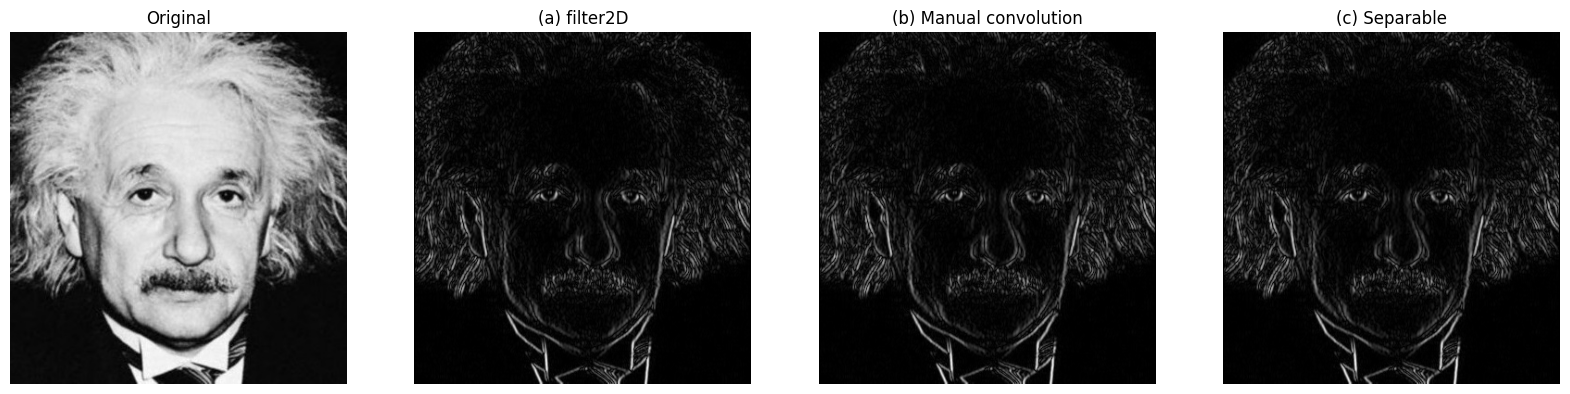

Max difference (a) vs (b): 0.0
Max difference (a) vs (c): 0.0


In [51]:
einstein = cv2.imread('Einstein.jpeg', cv2.IMREAD_GRAYSCALE)
assert einstein is not None

sobel_x = np.array([[1, 0, -1],
                     [2, 0, -2],
                     [1, 0, -1]], dtype=np.float32)

# (a) Using OpenCV's filter2D
sobel_a = cv2.filter2D(einstein.astype(np.float32), -1, sobel_x)

# (b) Manual convolution, written from scratch
def my_sobel(img_gray, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img_gray, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect').astype(np.float32)
    out = np.zeros_like(img_gray, dtype=np.float32)
    for i in range(img_gray.shape[0]):
        for j in range(img_gray.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)
    return out

sobel_b = my_sobel(einstein, sobel_x)

# (c) Separable convolution: split the 2D kernel into two 1D passes
col = np.array([[1], [2], [1]], dtype=np.float32)   # vertical smoothing
row = np.array([[1, 0, -1]], dtype=np.float32)       # horizontal derivative

temp = cv2.filter2D(einstein.astype(np.float32), -1, col)
sobel_c = cv2.filter2D(temp, -1, row)

# Display all three results side-by-side
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(einstein, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(np.abs(sobel_a), cmap='gray'); ax[1].set_title("(a) filter2D"); ax[1].axis('off')
ax[2].imshow(np.abs(sobel_b), cmap='gray'); ax[2].set_title("(b) Manual convolution"); ax[2].axis('off')
ax[3].imshow(np.abs(sobel_c), cmap='gray'); ax[3].set_title("(c) Separable"); ax[3].axis('off')
plt.show()

# Verify all three methods agree
diff_ab = np.abs(sobel_a - sobel_b).max()
diff_ac = np.abs(sobel_a - sobel_c).max()
print(f"Max difference (a) vs (b): {diff_ab}")
print(f"Max difference (a) vs (c): {diff_ac}")